# 手动实现二维卷积与Pytorch实现二维卷积比较
韩佳轩，23281106，计算机科学与技术学院

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt
import os

In [2]:
# 设置随机种子
torch.manual_seed(23281106)

In [3]:
# 使用GPU进行训练
device = torch.device("cuda:0")

## 手动实现卷积运算

In [4]:
def corr2d(X,K):
    """
    定义单通道卷积操作
    X: shape (batch_size,H,W)
    K:  shape (k_h,k_w)
    """
    batch_size,H, W = X.shape
    k_h, k_w = K.shape
    #初始化结果矩阵
    Y = torch.zeros((batch_size,H - k_h + 1,W - k_w + 1)).to(device)
    for i in range(Y.shape[1]):
        for j in range(Y.shape[2]):
            Y[:,i, j] = (X[:,i: i + k_h, j: j + k_w] * K).sum(dim=2).sum(dim=1)
    return Y

def corr2d_multi_in(X, K):
    """
    定义多输入通道卷积操作
    X：shape (batch_size,C_in,H,W)
    K：shape (C_in,k_h,k_w)
    Y：shape (batch_size,H_out,W_out)
    """
    res = corr2d(X[:,0, :, :], K[0, :, :])
    for i in range(1, X.shape[1]):
        #按通道相加
        res += corr2d(X[:,i, :, :], K[i, :, :])
    return res

def corr2d_multi_in_out(X, K):
    """
    定义多输入/输出通道卷积操作
    X：shape (batch_size,C_in,H,W)
    K：shape (C_out,C_in,h,w)
    Y：shape(batch_size,C_out,H_out,W_out)
    """
    return torch.stack([corr2d_multi_in(X, k) for k in K],dim=1)

## 实现自定义卷积层

In [5]:
class MyConv2D(nn.Module):
    """
    实现自定义卷积层
    """
    def __init__(self, in_channels, out_channels, kernel_size):
        super(MyConv2D, self).__init__()
        #初始化卷积层的2个参数：卷积核、偏差
        if isinstance(kernel_size,int):
            kernel_size = (kernel_size,kernel_size)
        self.weight = nn.Parameter(torch.randn((out_channels,in_channels)+kernel_size))
        self.bias = nn.Parameter(torch.randn(out_channels,1,1))

    def forward(self, x):
        """
        x：输入图片，维度(batch_size,C_in,H,W)
        """
        return corr2d_multi_in_out(x, self.weight) + self.bias

In [6]:
class MyConvModule(nn.Module):
    def __init__(self):
        super(MyConvModule, self).__init__()
        # 定义一层卷积
        self.conv = nn.Sequential(
            MyConv2D(in_channels=3, out_channels=32,kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )
        # 输出层，将通道数变为分类数量
        self.fc = nn.Linear(32, num_classes)

    def forward(self, X):
        # 图片先经过一层卷积,输出维度(batch_size,C_out,H,W)
        out = self.conv(X)
        # 使用平均池化层将图片的大小变为1x1
        out = F.avg_pool2d(out, 30)
        # 将张量out从shape batch x 32 x 1 x 1 变为 batch x 32
        out = out.squeeze()
        # 输入到全连接层将输出的维度变为10
        out = self.fc(out)
        return out

## 使用Pytorch自带卷积

In [7]:
class ConvModule(nn.Module):
    def __init__(self):
        super(ConvModule, self).__init__()
        # 定义一个三层卷积
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, 
                      kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, stride=1,padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=64, out_channels=128, 
                      kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True)
        )
        # 输出层，将通道数变为分类数量
        self.fc = nn.Linear(128, num_classes)

    def forward(self, X):
        # 图片先经过三层卷积,输出维度(batch_size,C_out,H,W)
        out = self.conv(X)
        # 使用平均池化层将图片的大小变为1x1
        out = F.avg_pool2d(out, 26)
        # 将张量out从shape batch x 128 x 1 x 1 变为 batch x 128
        out = out.squeeze()
        # 输入到全连接层将输出的维度变为10
        out = self.fc(out)
        return out

## 自定义卷积模型训练

In [8]:
def my_train_epoch(net, data_loader, device):
    
    net.train() # 指定当前为训练模式
    train_batch_num = len(data_loader) # 记录共有多少个batch
    total_loss = 0 # 记录Loss
    correct = 0  # 记录共有多少个样本被正确分类
    sample_num = 0 # 记录样本总数
    
    # 遍历每个batch进行训练
    for batch_idx, (data, target) in enumerate(data_loader):
        # 将图片放入指定的device中
        data = data.to(device).float()
        # 将图片标签放入指定的device中
        target = target.to(device).long()
        # 将当前梯度清零
        optimizer.zero_grad()
        # 使用模型计算出结果
        output = net(data)
        # 计算损失
        loss = criterion(output, target)
        # 进行反向传播
        loss.backward()
        optimizer.step()
        # 累加Loss
        total_loss += loss.item()
        # 找出每个样本值最大的idx，即代表预测此图片属于哪个类别
        prediction = torch.argmax(output, 1)
        # 统计预测正确的类别数量
        correct += (prediction == target).sum().item()
        # 累加当前的样本总数
        sample_num += len(prediction)
        
        mean_loss = total_loss / (batch_idx+1)#计算一个batch的平均训练损失
        mean_acc = correct / sample_num#计算一个batch的平均准确率
        print(f"epoch-batch:{epoch}-{batch_idx}\t train_loss:{mean_loss:.4f} \t"
          f"train_acc:{mean_acc:.4f}")
    # 计算平均的loss与准确率
    loss = total_loss / train_batch_num#计算一轮中平均batch的loss
    acc = correct / sample_num#计算一轮所有bacth的准确率
    return loss, acc

In [9]:
def my_test_epoch(net, data_loader, device):
    net.eval() # 指定当前模式为测试模式
    test_batch_num = len(data_loader)
    total_loss = 0
    correct = 0  
    sample_num = 0
    # 指定不进行梯度变化
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            data = data.to(device).float()
            target = target.to(device).long()
            output = net(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            prediction = torch.argmax(output, 1)
            correct += (prediction == target).sum().item()
            sample_num += len(prediction)
            
            mean_loss = total_loss / (batch_idx+1)
            mean_acc = correct / sample_num
            print(f"epoch-batch:{epoch}-{batch_idx}\t test_loss:{mean_loss:.4f} \t"
              f"test_acc:{mean_acc:.4f}")
    loss = total_loss / test_batch_num
    acc = correct / sample_num
    return loss, acc

## pytorch的模型训练

In [10]:
def train_epoch(net, data_loader, device):
    
    net.train() # 指定当前为训练模式
    train_batch_num = len(data_loader) # 记录共有多少个batch
    total_loss = 0 # 记录Loss
    correct = 0  # 记录共有多少个样本被正确分类
    sample_num = 0 # 记录样本总数
    
    # 遍历每个batch进行训练
    for batch_idx, (data, target) in enumerate(data_loader):
        # 将图片放入指定的device中
        data = data.to(device).float()
        # 将图片标签放入指定的device中
        target = target.to(device).long()
        # 将当前梯度清零
        optimizer.zero_grad()
        # 使用模型计算出结果
        output = net(data)
        # 计算损失
        loss = criterion(output, target)
        # 进行反向传播
        loss.backward()
        optimizer.step()
        # 累加Loss
        total_loss += loss.item()
        # 找出每个样本值最大的idx，即代表预测此图片属于哪个类别
        prediction = torch.argmax(output, 1)
        # 统计预测正确的类别数量
        correct += (prediction == target).sum().item()
        # 累加当前的样本总数
        sample_num += len(prediction)
    # 计算平均的loss与准确率
    loss = total_loss / train_batch_num#计算一轮中平均batch的loss
    acc = correct / sample_num#计算一轮所有bacth的准确率
    return loss, acc

In [11]:
def test_epoch(net, data_loader, device):
    net.eval() # 指定当前模式为测试模式
    test_batch_num = len(data_loader)
    total_loss = 0
    correct = 0  
    sample_num = 0
    # 指定不进行梯度变化
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            data = data.to(device).float()
            target = target.to(device).long()
            output = net(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            prediction = torch.argmax(output, 1)
            correct += (prediction == target).sum().item()
            sample_num += len(prediction)
    loss = total_loss / test_batch_num
    acc = correct / sample_num
    return loss, acc

## 读取数据并配置实验参数

In [12]:
data_dir = './data' # 指定数据的位置
# 定义一个transform操作，用户将torch中的数据转换为可以输入到我们模型的形式
transform = transforms.Compose(
    [transforms.ToTensor(), # 首先将数据转换为Tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]) # 将数据进行归一化，前一个参数代表mean，后一个代表std
# 获取cifar-10数据集并进行transform
cifar_train = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
cifar_test = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
# cifar-10数据集对应的10个类别
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
num_classes = 10 # 共十类
epochs = 100 # 训练多少轮
lr = 0.001 # 学习率
batch_size = 512 # batch大小
# 生成dataloader
cifar_trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=batch_size,
                                                shuffle=True, num_workers=0)
cifar_testloader = torch.utils.data.DataLoader(cifar_test, batch_size=512,
                                               shuffle=True, num_workers=0)
# 初始化模型
#下面模型2选1，自定义卷积模型/pytorch自带卷积模型
net = MyConvModule().to(device)
# net = ConvModule().to(device)

# 使用多元交叉熵损失
criterion = nn.CrossEntropyLoss()
# 使用Adam优化器
optimizer = optim.Adam(net.parameters(), lr=lr)

## 自定义卷积实验

In [13]:
# 存储每一个epoch的loss与acc的变化，便于后面可视化
import time


train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []

my_start_time = time.time()

# 进行训练
for epoch in range(epochs):
    # 在训练集上训练
    train_loss, train_acc = my_train_epoch(net, data_loader=cifar_trainloader, device=device)
    # 在测试集上验证
    test_loss, test_acc = my_test_epoch(net, data_loader=cifar_testloader, device=device)
    # 保存各个指标
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    print(f"epoch:{epoch}\t train_loss:{train_loss:.4f} \t"
          f"train_acc:{train_acc} \t"
          f"test_loss:{test_loss:.4f} \t test_acc:{test_acc} \t Time:{time.time() - my_start_time}")

epoch-batch:0-0	 train_loss:2.3641 	train_acc:0.1094
epoch-batch:0-1	 train_loss:2.3650 	train_acc:0.1055
epoch-batch:0-2	 train_loss:2.3538 	train_acc:0.1133
epoch-batch:0-3	 train_loss:2.3547 	train_acc:0.1108
epoch-batch:0-4	 train_loss:2.3565 	train_acc:0.1078
epoch-batch:0-5	 train_loss:2.3562 	train_acc:0.1048
epoch-batch:0-6	 train_loss:2.3573 	train_acc:0.1035
epoch-batch:0-7	 train_loss:2.3552 	train_acc:0.1050
epoch-batch:0-8	 train_loss:2.3528 	train_acc:0.1039
epoch-batch:0-9	 train_loss:2.3512 	train_acc:0.1014
epoch-batch:0-10	 train_loss:2.3495 	train_acc:0.1019
epoch-batch:0-11	 train_loss:2.3474 	train_acc:0.1035
epoch-batch:0-12	 train_loss:2.3456 	train_acc:0.1032
epoch-batch:0-13	 train_loss:2.3437 	train_acc:0.1032
epoch-batch:0-14	 train_loss:2.3430 	train_acc:0.1027
epoch-batch:0-15	 train_loss:2.3410 	train_acc:0.1039
epoch-batch:0-16	 train_loss:2.3392 	train_acc:0.1044
epoch-batch:0-17	 train_loss:2.3381 	train_acc:0.1050
epoch-batch:0-18	 train_loss:2.3367 	t

KeyboardInterrupt: 

### Loss曲线

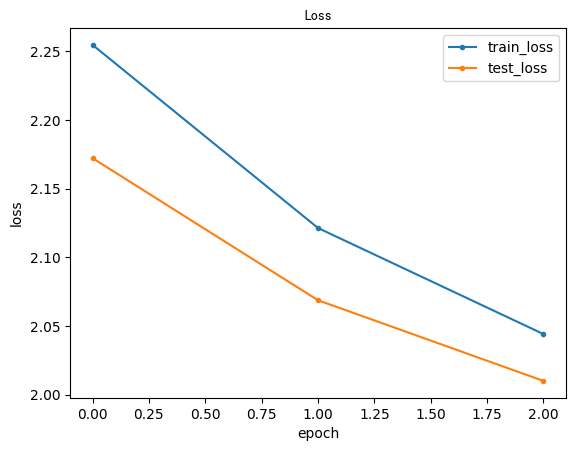

In [14]:
train, = plt.plot(train_loss_list,'.-',label='train_loss')
test, = plt.plot(test_loss_list,'.-',label='test_loss')
plt.title("Loss",fontsize=14,fontproperties='SimHei')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend([train,test],["train_loss", "test_loss"],loc='upper right')
plt.show()

### Acc曲线

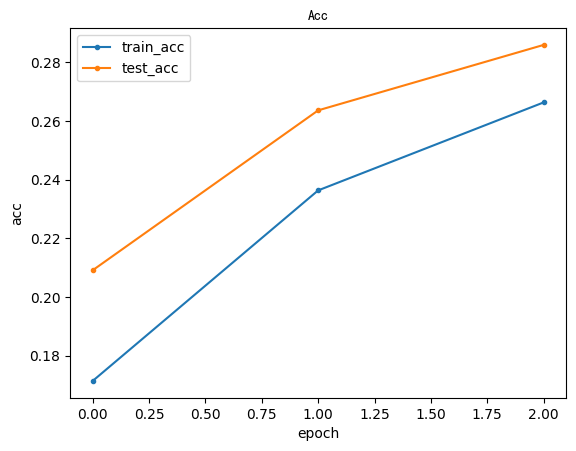

In [15]:
train, = plt.plot(train_acc_list,'.-',label='train_acc')
test, = plt.plot(test_acc_list,'.-',label='test_acc')
plt.title("Acc",fontsize=14,fontproperties='SimHei')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend([train,test],["train_acc", "test_acc"],loc='upper left')
plt.show()

## Pytorch自带卷积实验

In [16]:
# 存储每一个epoch的loss与acc的变化，便于后面可视化
train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []

torch_time_start = time.time()

# 进行训练
for epoch in range(epochs):
    # 设置Pytorch卷积
    net = ConvModule().to(device)
    # 在训练集上训练
    train_loss, train_acc = train_epoch(net, data_loader=cifar_trainloader, device=device)
    # 在测试集上验证
    test_loss, test_acc = test_epoch(net, data_loader=cifar_testloader, device=device)
    # 保存各个指标
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    print(f"epoch:{epoch}\t train_loss:{train_loss:.4f} \t"
          f"train_acc:{train_acc} \t"
          f"test_loss:{test_loss:.4f} \t test_acc:{test_acc} \t Time:{time.time() - torch_time_start}")

epoch:0	 train_loss:2.3270 	train_acc:0.10158 	test_loss:2.3267 	 test_acc:0.0994 	 Time:11.910935640335083
epoch:1	 train_loss:2.3664 	train_acc:0.10016 	test_loss:2.3678 	 test_acc:0.1002 	 Time:23.690305948257446
epoch:2	 train_loss:2.3270 	train_acc:0.10828 	test_loss:2.3272 	 test_acc:0.1078 	 Time:35.733935832977295
epoch:3	 train_loss:2.3077 	train_acc:0.08692 	test_loss:2.3097 	 test_acc:0.0843 	 Time:47.83937168121338
epoch:4	 train_loss:2.3169 	train_acc:0.11702 	test_loss:2.3185 	 test_acc:0.1181 	 Time:60.13895654678345
epoch:5	 train_loss:2.3312 	train_acc:0.09164 	test_loss:2.3296 	 test_acc:0.0881 	 Time:72.34044933319092
epoch:6	 train_loss:2.3466 	train_acc:0.10396 	test_loss:2.3467 	 test_acc:0.1031 	 Time:84.25030446052551
epoch:7	 train_loss:2.3209 	train_acc:0.12154 	test_loss:2.3223 	 test_acc:0.1161 	 Time:96.0986487865448
epoch:8	 train_loss:2.3223 	train_acc:0.09908 	test_loss:2.3222 	 test_acc:0.0944 	 Time:107.99853515625
epoch:9	 train_loss:2.3618 	train_acc

### Loss曲线

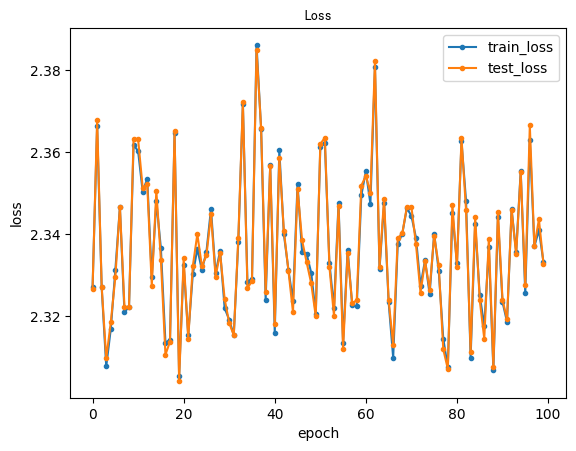

In [17]:
train, = plt.plot(train_loss_list,'.-',label='train_loss')
test, = plt.plot(test_loss_list,'.-',label='test_loss')
plt.title("Loss",fontsize=14,fontproperties='SimHei')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend([train,test],["train_loss", "test_loss"],loc='upper right')
plt.show()

### Acc曲线

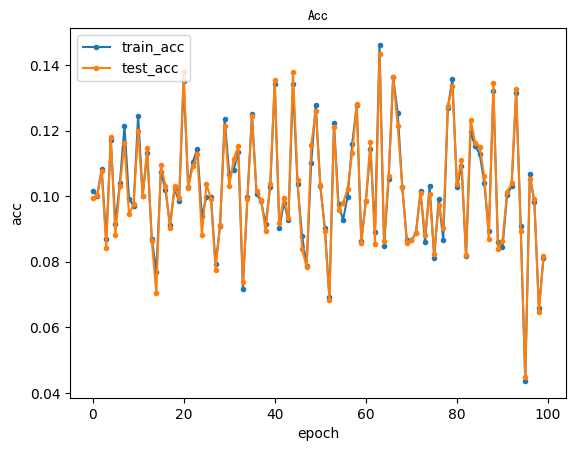

In [18]:
train, = plt.plot(train_acc_list,'.-',label='train_acc')
test, = plt.plot(test_acc_list,'.-',label='test_acc')
plt.title("Acc",fontsize=14,fontproperties='SimHei')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend([train,test],["train_acc", "test_acc"],loc='upper left')
plt.show()

## 不同超参数对比分析

卷积核的大小影响着最终训练质量。较小的卷积核对源数据保持较好，但数据量大，较大的卷积核反之。